In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
# Load training data
data = pd.read_csv('../data/claims_train.csv')

In [3]:
df = data.copy()

# Cap exposure
df["Exposure"] = df["Exposure"].clip(upper=1.0)

# Targets
y_rate = (df["ClaimNb"] / df["Exposure"]).astype(float)
w_expo = df["Exposure"].astype(float)

# Feature engineering
df["LogBonus"] = np.log(df["BonusMalus"])
df["LogDensity"] = np.log(df["Density"])

cats_to_encode = ["VehBrand", "VehGas", "Region"]
keep_cols = ["VehPower", "VehAge", "DrivAge", "LogBonus", "LogDensity"]

X = pd.get_dummies(
    df[keep_cols + cats_to_encode],
    columns=cats_to_encode,
    drop_first=True
)

# Scale for PCA
X_scaled = StandardScaler().fit_transform(X)

numeric_cols = keep_cols
dummy_cols = [c for c in X.columns if c not in numeric_cols]

In [4]:

# Numeric + dummy
X_num_dummy = X[numeric_cols + dummy_cols]
X_num_dummy_scaled = StandardScaler().fit_transform(X_num_dummy)


# Numeric + dummy PCA
pca_all = PCA().fit(X_num_dummy_scaled)
expl_all = pca_all.explained_variance_ratio_
cum_all = np.cumsum(expl_all)

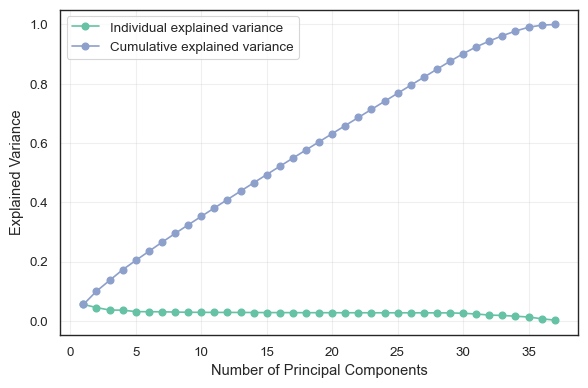

In [37]:
sns.set_theme(style="white", context="paper", font_scale=1.1)

pcs_num = np.arange(1, len(expl_all) + 1)

plt.figure(figsize=(6, 4))

# Individual explained variance
plt.plot(pcs_num, expl_all, marker='o', label='Individual explained variance', color=sns.color_palette("Set2")[0])

# Cumulative explained variance
plt.plot(pcs_num, cum_all, marker='o', label='Cumulative explained variance', color=sns.color_palette("Set2")[2])

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/2screeplot.png",dpi=300,bbox_inches="tight")
plt.show()


for 2 PCs - 0.100 variance explained
k=2: silhouette=0.363
k=3: silhouette=0.408
k=4: silhouette=0.362
k=5: silhouette=0.369
k=6: silhouette=0.370
for 3 PCs - 0.136 variance explained
k=2: silhouette=0.295
k=3: silhouette=0.309
k=4: silhouette=0.346
k=5: silhouette=0.292
k=6: silhouette=0.296
for 4 PCs - 0.173 variance explained
k=2: silhouette=0.244
k=3: silhouette=0.247
k=4: silhouette=0.277
k=5: silhouette=0.276
k=6: silhouette=0.265


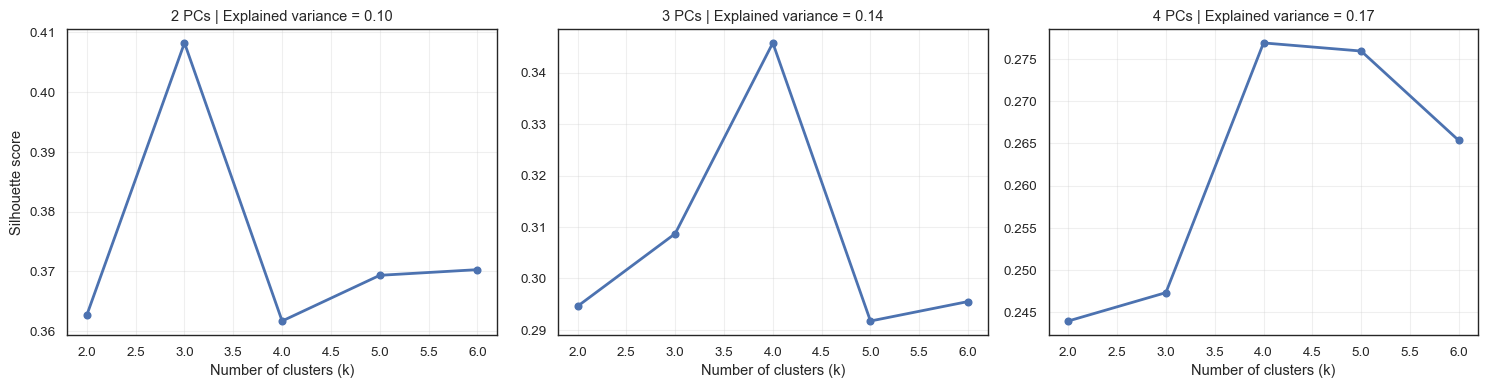

In [39]:
# set random seed
rng = np.random.default_rng(42)
ks = [2, 3, 4, 5, 6] # range of k values
pcs = [2, 3, 4] # number of principal components

fig, axes = plt.subplots(1, len(pcs), figsize=(15, 4))

for ax, n in zip(axes, pcs):
    # compute pca 
    pca = PCA(n_components=n, random_state=42)
    X_pca = pca.fit_transform(X_num_dummy_scaled)

    # find variance explaines
    var = pca.explained_variance_ratio_.sum()

    # use subsample of data for silhouette score of 5000 
    idx = rng.choice(len(X_pca), size=5000, replace=False)

    print(f"for {n} PCs - {var:.3f} variance explained")

    silhouette_scores = []

    for k in ks:
        labels = KMeans(n_clusters=k, n_init=10,random_state=42).fit_predict(X_pca)
        score = silhouette_score(X_pca[idx], labels[idx])
        silhouette_scores.append(score)
        
        print(f"k={k}: silhouette={score:.3f}")

    # --- Plot ---
    ax.plot(ks, silhouette_scores, marker="o", linewidth=2)
    ax.set_title(f"{n} PCs | Explained variance = {var:.2f}")
    ax.set_xlabel("Number of clusters (k)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/2silhoettetuning", dpi=300, bbox_inches="tight")
plt.show()

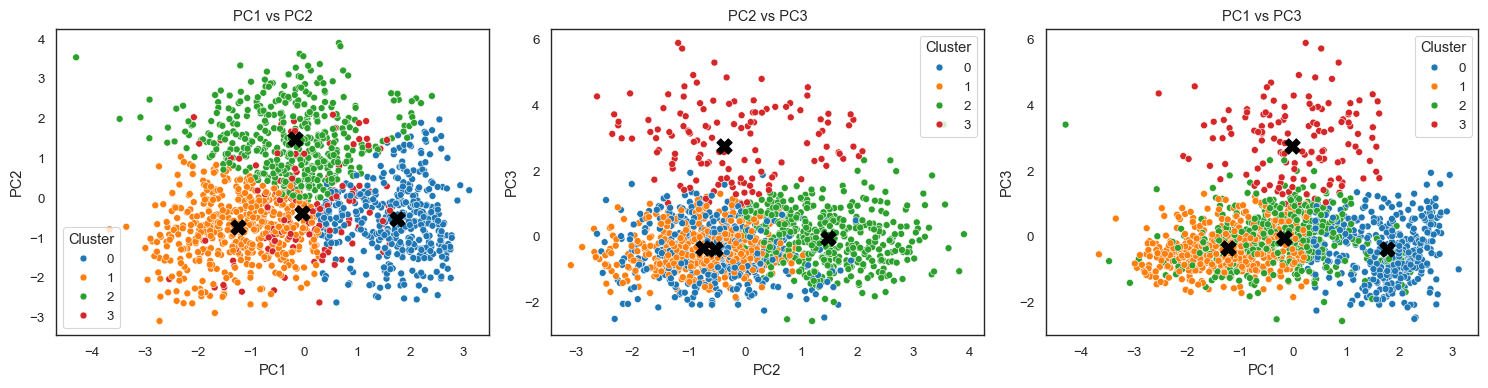

In [40]:

# PCA (3 components)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_num_dummy_scaled)

# K-means clustering (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

# Color palette for clusters
cluster_order = sorted(np.unique(labels))   # [0,1,2]
base = sns.color_palette("tab10", n_colors=len(cluster_order))
palette_map = {c: base[i] for i, c in enumerate(cluster_order)}


# Small subsample for plotting to avoid one big blob
rng = np.random.default_rng(42)
idx = rng.choice(len(X_pca), size=1500, replace=False)

plot_df = pd.DataFrame(X_pca[idx],columns=["PC1", "PC2", "PC3"])
plot_df["Cluster"] = labels[idx]
plot_df["Cluster"] = plot_df["Cluster"].astype(int)

# plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#PC1vPC2
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", hue_order=cluster_order, palette=palette_map,ax=axes[0], s=25)
axes[0].scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=120)
axes[0].set_title("PC1 vs PC2")
#PC2vPC3
sns.scatterplot(data=plot_df, x="PC2", y="PC3", hue="Cluster",  hue_order=cluster_order, palette=palette_map, ax=axes[1], s=25)
axes[1].scatter(centroids[:, 1], centroids[:, 2], c="black", marker="X", s=120)
axes[1].set_title("PC2 vs PC3")
# PC1vPC3
sns.scatterplot(data=plot_df, x="PC1", y="PC3",hue="Cluster", hue_order=cluster_order, palette=palette_map,ax=axes[2], s=25)
axes[2].scatter(centroids[:, 0], centroids[:, 2],c="black", marker="X", s=120)
axes[2].set_title("PC1 vs PC3")

plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/2pairplotpca", dpi=300, bbox_inches="tight")
plt.show()

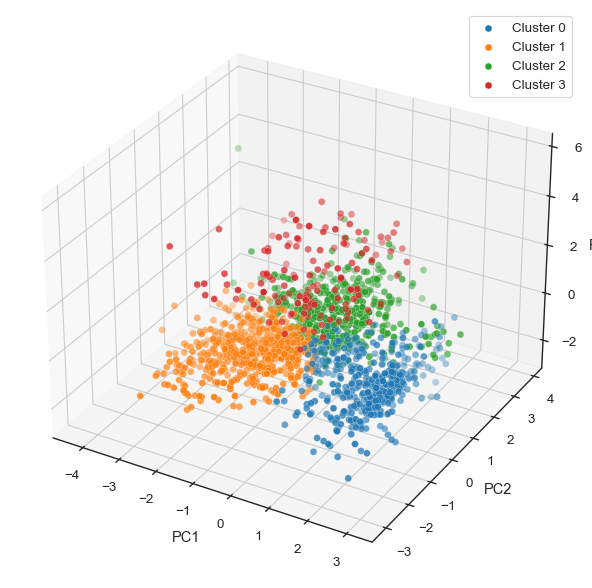

In [41]:
X_plot = X_pca[idx]
labels_plot = labels[idx]
palette = [palette_map[c] for c in cluster_order] # colors

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for k in range(4):
    pts = X_plot[labels_plot == k]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color=palette[k],s=25, edgecolor="white", linewidth=0.2, label=f"Cluster {k}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()

plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/23dplot", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
# define loadings in pc's
loadings = pd.DataFrame(pca.components_.T,columns=[f"PC{i+1}" for i in range(pca.n_components_)],index=X.columns)
# print absolute loadings...
for i in range(pca.n_components_):
    pc = (loadings.iloc[:, i].abs().sort_values(ascending=False).head(5))
    print(f"\nTop 5 absolute for PC{i+1}:")
    print(pc)



Top 5 absolute for PC1:
VehBrand_B12    0.539748
Region_R24      0.443877
VehAge          0.439525
VehBrand_B2     0.325451
LogDensity      0.309061
Name: PC1, dtype: float64

Top 5 absolute for PC2:
LogBonus       0.590517
DrivAge        0.567127
LogDensity     0.314148
Region_R24     0.196660
VehBrand_B3    0.170917
Name: PC2, dtype: float64

Top 5 absolute for PC3:
VehPower        0.540937
VehBrand_B10    0.444832
VehBrand_B11    0.355444
Region_R82      0.266212
VehAge          0.222551
Name: PC3, dtype: float64


In [52]:
# Select key columns for summary
cols = ["ClaimNb", "Exposure", "Claim_rate", "DrivAge", "VehAge", "VehPower", "BonusMalus", "Density"]

# Compute simple cluster means + counts
summary = data.groupby("Cluster")[cols].mean().round(2)
summary["Count"] = data["Cluster"].value_counts().sort_index().values

print("\n=== Cluster Summary (mean values) ===")
print(summary)


=== Cluster Summary (mean values) ===
         ClaimNb  Exposure  Claim_rate  DrivAge  VehAge  VehPower  BonusMalus  \
Cluster                                                                         
0           0.05      0.42         NaN    50.08    2.53      6.75       55.26   
1           0.05      0.66        0.09    50.33    9.02      6.03       53.18   
2           0.06      0.47        0.12    34.96    8.33      5.88       72.81   
3           0.05      0.55         NaN    47.76    9.09      9.15       55.69   

         Density   Count  
Cluster                   
0        2623.17  148484  
1         472.78  186906  
2        2483.10  160133  
3        2106.63   46887  


/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_58114/2106321808.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["Claim_rate"] = data.groupby("Cluster").apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())
/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_58114/2106321808.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Cluster_str", y="Claim_rate", order=cluster_order_str, palette=palette_map_str, estimator=np.mean)


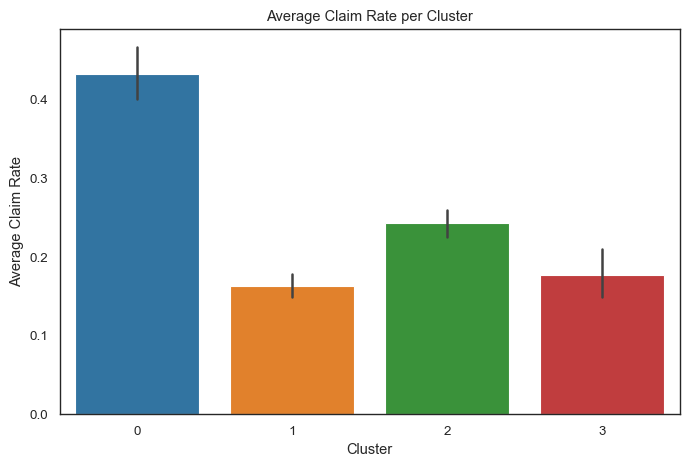

In [53]:
# Add cluster labels from your PCA/KMeans results
data["Cluster"] = labels

# assign mean claim rate per cluster
data["Claim_rate"] = data.groupby("Cluster").apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())
# ensure int
df["Cluster_str"] = df["Cluster"].astype(str)

cluster_order_str = sorted(df["Cluster_str"].unique(), key=int) # color
palette_map_str = {c: base[i] for i, c in enumerate(cluster_order_str)} # keep color from plot 

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Cluster_str", y="Claim_rate", order=cluster_order_str, palette=palette_map_str, estimator=np.mean)

plt.title("Average Claim Rate per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Claim Rate")
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/2claimrate", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
# printing the mode of most popular categorical variables per cluster
print("\nMost common Area per cluster:")
print(data.groupby("Cluster")["Area"].agg(lambda x: x.mode()[0]))
print("\nMost common Region per cluster:")
print(data.groupby("Cluster")["Region"].agg(lambda x: x.mode()[0]))
print("\nMost common Vehicle brand per cluster:")
print(data.groupby("Cluster")["VehBrand"].agg(lambda x: x.mode()[0]))
print("\nMost common Fuel Type per cluster:")
print(data.groupby("Cluster")["VehGas"].agg(lambda x: x.mode()[0]))



Most common Area per cluster:
Cluster
0    E
1    C
2    E
3    C
Name: Area, dtype: object

Most common Region per cluster:
Cluster
0    R93
1    R24
2    R82
3    R82
Name: Region, dtype: object

Most common Vehicle brand per cluster:
Cluster
0    B12
1     B2
2     B1
3    B10
Name: VehBrand, dtype: object

Most common Fuel Type per cluster:
Cluster
0    Regular
1     Diesel
2    Regular
3     Diesel
Name: VehGas, dtype: object


In [13]:
# printing mean, std, min, max for key columns per cluster
for col in ["Claim_rate", "Exposure", "ClaimNb", "DrivAge", "VehAge", "BonusMalus"]:
    print(f"\n{col}:")
    print(data.groupby("Cluster")[col].describe()[["mean", "std", "min", "max"]])



Claim_rate:
             mean       std  min    max
Cluster                                
0        0.435415  6.326074  0.0  732.0
1        0.162478  3.304044  0.0  366.0
2        0.224310  3.519459  0.0  366.0

Exposure:
             mean       std       min   max
Cluster                                    
0        0.411617  0.313116  0.002732  2.01
1        0.659716  0.365102  0.002732  2.01
2        0.489348  0.360661  0.002732  2.00

ClaimNb:
             mean       std  min   max
Cluster                               
0        0.050840  0.234713  0.0   4.0
1        0.051910  0.235370  0.0  11.0
2        0.056105  0.245191  0.0   4.0

DrivAge:
              mean        std   min    max
Cluster                                   
0        49.540810  13.353230  18.0  100.0
1        50.274187  13.845236  18.0   99.0
2        37.606352  11.264268  18.0   99.0

VehAge:
             mean       std  min    max
Cluster                                
0        2.448972  2.671696  0.0   27